### Data Preprocessing Project

### Topic: Missing Value Imputation,Outlier Detection,Normalization,Standardization & Pipline

### Q1: Exploratory Data Analysis(EDA)

In [1]:
import numpy as np
import pandas as pd
ur1="https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df=pd.read_csv(ur1)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
df.shape

(891, 12)

In [3]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [4]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [5]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# Obsevation :-

The dataset contains both numerical and categorical columns.Missing values are present mainly in Age,Cabin,and Embarked columns.Cabin has the highest number of missing values.


### Q2: Missing Value Visualization

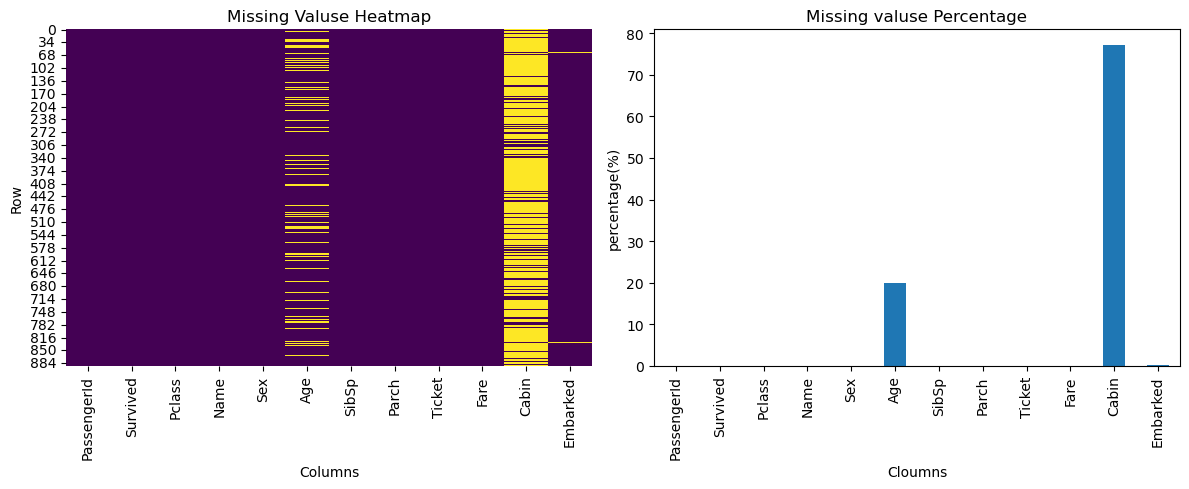

In [6]:
import pandas as plt
import seaborn as sns
import matplotlib.pyplot as plt
ur1="https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df=pd.read_csv(ur1)
df.head()

plt.figure(figsize=(12,5))

#heatmap
plt.subplot(1,2,1)
sns.heatmap(df.isnull(), cbar=False,cmap='viridis')
plt.title("Missing Valuse Heatmap")
plt.xlabel("Columns")
plt.ylabel("Row")

#bar chart
plt.subplot(1,2,2)
missing_percent =df.isnull().mean() * 100
missing_percent.plot(kind='bar')
plt.title("Missing valuse Percentage")
plt.xlabel("Cloumns")
plt.ylabel("percentage(%)")
# plt.savefig("Missing_valuse_Percentage.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

# Obsevation :-

The heatmap clearly shows missing data patterns in the dataset. Cabin has the hihest percentage od missing values,follwed ny Age.Embarked has very few missing values.

### Q3: Mean, Median, and Mode Imputation — Manual Comparison

mean: 29.69911764705882
median: 28.0
mode: 0    24.0
Name: Age, dtype: float64


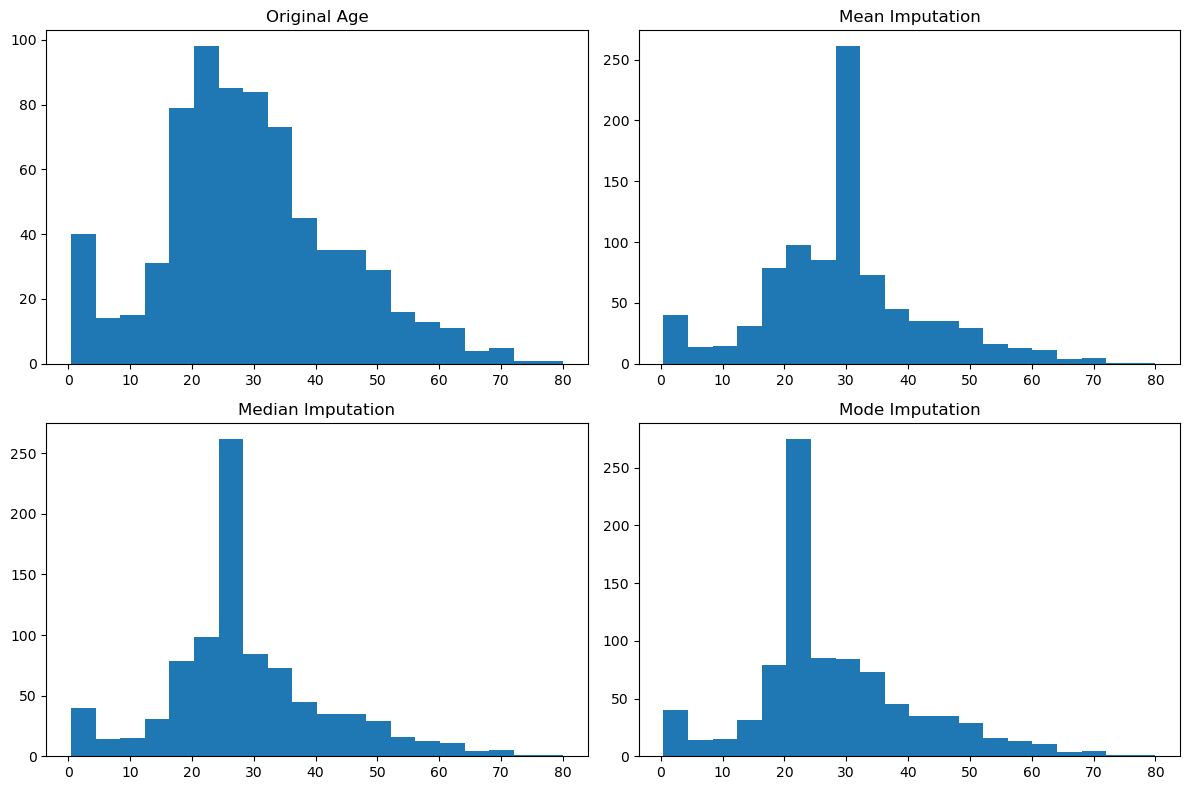

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
ur1="https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df=pd.read_csv(ur1)
df.head()

# Create copies
mean = df.copy()
median = df.copy()
mode = df.copy()

# Imputation
mean['Age'] = mean['Age'].fillna(mean['Age'].mean())

median['Age'] = median['Age'].fillna(median['Age'].median())

mode['Age'] = mode['Age'].fillna(mode['Age'].mode()[0])

# Mean and Standard Deviation
print("mean:",df['Age'].mean())
print("median:",df['Age'].median())
print("mode:",df['Age'].mode())

# Histograms
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.hist(df['Age'].dropna(), bins=20)
plt.title("Original Age")

plt.subplot(2,2,2)
plt.hist(mean['Age'], bins=20)
plt.title("Mean Imputation")

plt.subplot(2,2,3)
plt.hist(median['Age'], bins=20)
plt.title("Median Imputation")

plt.subplot(2,2,4)
plt.hist(mode['Age'], bins=20)
plt.title("Mode Imputation")
# plt.savefig("Imputation.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

# Observation:-

Median imputation best preserves the original distribution.
Mean Imputation: Keeps the mean unchanged but reduces variability (standard deviation decreases).
Median Imputation: Preserves the central tendency while being robust to outliers.
Mode Imputation: Creates a spike at the most frequent age value, which can distort the distribution

### Q4 SimpleImputer from scikit-learn

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
ur1="https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df=pd.read_csv(ur1)
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:

# Features and target
X = df.drop('Survived', axis=1)
y = df['Survived']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Numerical columns
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

# Categorical columns
cat_cols = ['Embarked', 'Cabin']

# Imputers
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

# Numerical imputation
X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_test[num_cols] = num_imputer.transform(X_test[num_cols])

# Categorical imputation
X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

# Check missing values
print("Training Set Missing Values:")
print(X_train.isnull().sum())

print("\nTest Set Missing Values:")
print(X_test.isnull().sum())

Training Set Missing Values:
PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

Test Set Missing Values:
PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


# Observation:-

The SimpleImputer successfully replaced all missing values in the numerical columns using the median strategy.Missing values in the categorical columns (Embarked and Cabin) were filled using the most frequent (mode) strategy.After applying the imputers, isnull().sum() confirmed that no NaN values remained in both the training and test datasets.

## Q5 Per-Class (Group-wise) Imputation

Mean Age for Survived = 0: 30.62617924528302
Mean Age for Survived = 1: 28.343689655172415


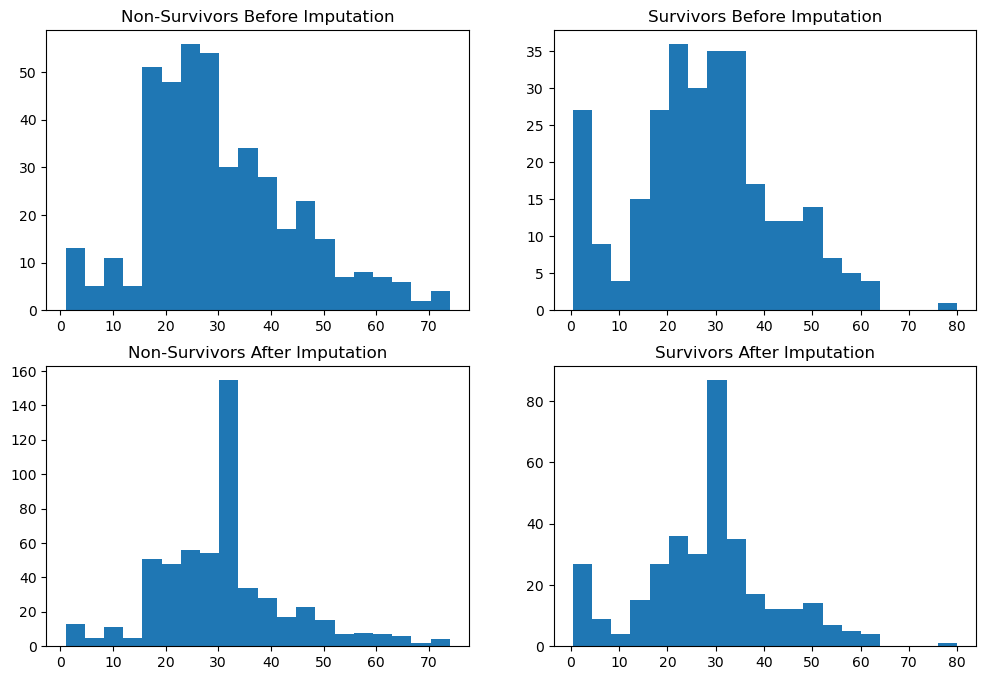

In [12]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
ur1="https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df=pd.read_csv(ur1)
df.head()

# Compute mean age for each survival group
group_means = df.groupby('Survived')['Age'].mean()

print("Mean Age for Survived = 0:", group_means[0])
print("Mean Age for Survived = 1:", group_means[1])

# Create a copy of the dataset
df_imputed = df.copy()

# Group-wise imputation
df_imputed['Age'] = df.groupby('Survived')['Age'].transform(
    lambda x: x.fillna(x.mean())
)

# Histograms
plt.figure(figsize=(12, 8))

# Before Imputation
plt.subplot(2, 2, 1)
plt.hist(df[df['Survived'] == 0]['Age'].dropna(), bins=20)
plt.title('Non-Survivors Before Imputation')

plt.subplot(2, 2, 2)
plt.hist(df[df['Survived'] == 1]['Age'].dropna(), bins=20)
plt.title('Survivors Before Imputation')

# After Imputation
plt.subplot(2, 2, 3)
plt.hist(df_imputed[df_imputed['Survived'] == 0]['Age'], bins=20)
plt.title('Non-Survivors After Imputation')

plt.subplot(2, 2, 4)
plt.hist(df_imputed[df_imputed['Survived'] == 1]['Age'], bins=20)
plt.title('Survivors After Imputation')
# plt.savefig("Imputation_After_Handling_MissingValues.png", dpi=300, bbox_inches="tight")
plt.show()

# Observation:-

The mean ages of survivors and non-survivors are different.Group-wise imputation replaces missing Age values using the mean of each survival group separately.

# Q6 Building a scikit-learn Pipeline

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
ur1="https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df=pd.read_csv(ur1)
df.head()

# Features and Target
X = df.drop('Survived', axis=1)
y = df['Survived']

# Select numerical columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X[num_cols], y, test_size=0.2, random_state=42)

# Create Pipeline
pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')),('scaler', StandardScaler())])

# Fit on training data only
pipeline.fit(X_train)

# Transform train and test data
X_train_transformed = pipeline.transform(X_train)
X_test_transformed = pipeline.transform(X_test)

# Convert to DataFrame
X_train_transformed = pd.DataFrame(X_train_transformed,columns=num_cols)

X_test_transformed = pd.DataFrame(X_test_transformed,columns=num_cols)

# Print first 5 rows
print("First 5 rows of transformed training data:")
print(X_train_transformed.head())

# Verify mean and standard deviation
print("\nMean of each column:")
print(X_train_transformed.mean())

print("\nStandard deviation of each column:")
print(X_train_transformed.std())

First 5 rows of transformed training data:
   PassengerId    Pclass       Age     SibSp     Parch      Fare
0    -0.453066 -1.614136  1.253641 -0.470722 -0.479342 -0.078684
1     1.113874 -0.400551 -0.477284 -0.470722 -0.479342 -0.377145
2    -0.254275  0.813034  0.215086 -0.470722 -0.479342 -0.474867
3     1.000836  0.813034 -0.246494  0.379923 -0.479342 -0.476230
4     1.425702  0.813034 -1.785093  2.931860  2.048742 -0.025249

Mean of each column:
PassengerId    8.482603e-17
Pclass         9.355812e-17
Age            1.746418e-17
SibSp          1.746418e-17
Parch          2.245395e-17
Fare           5.363999e-17
dtype: float64

Standard deviation of each column:
PassengerId    1.000703
Pclass         1.000703
Age            1.000703
SibSp          1.000703
Parch          1.000703
Fare           1.000703
dtype: float64


## Q7 Normalization vs Standardization

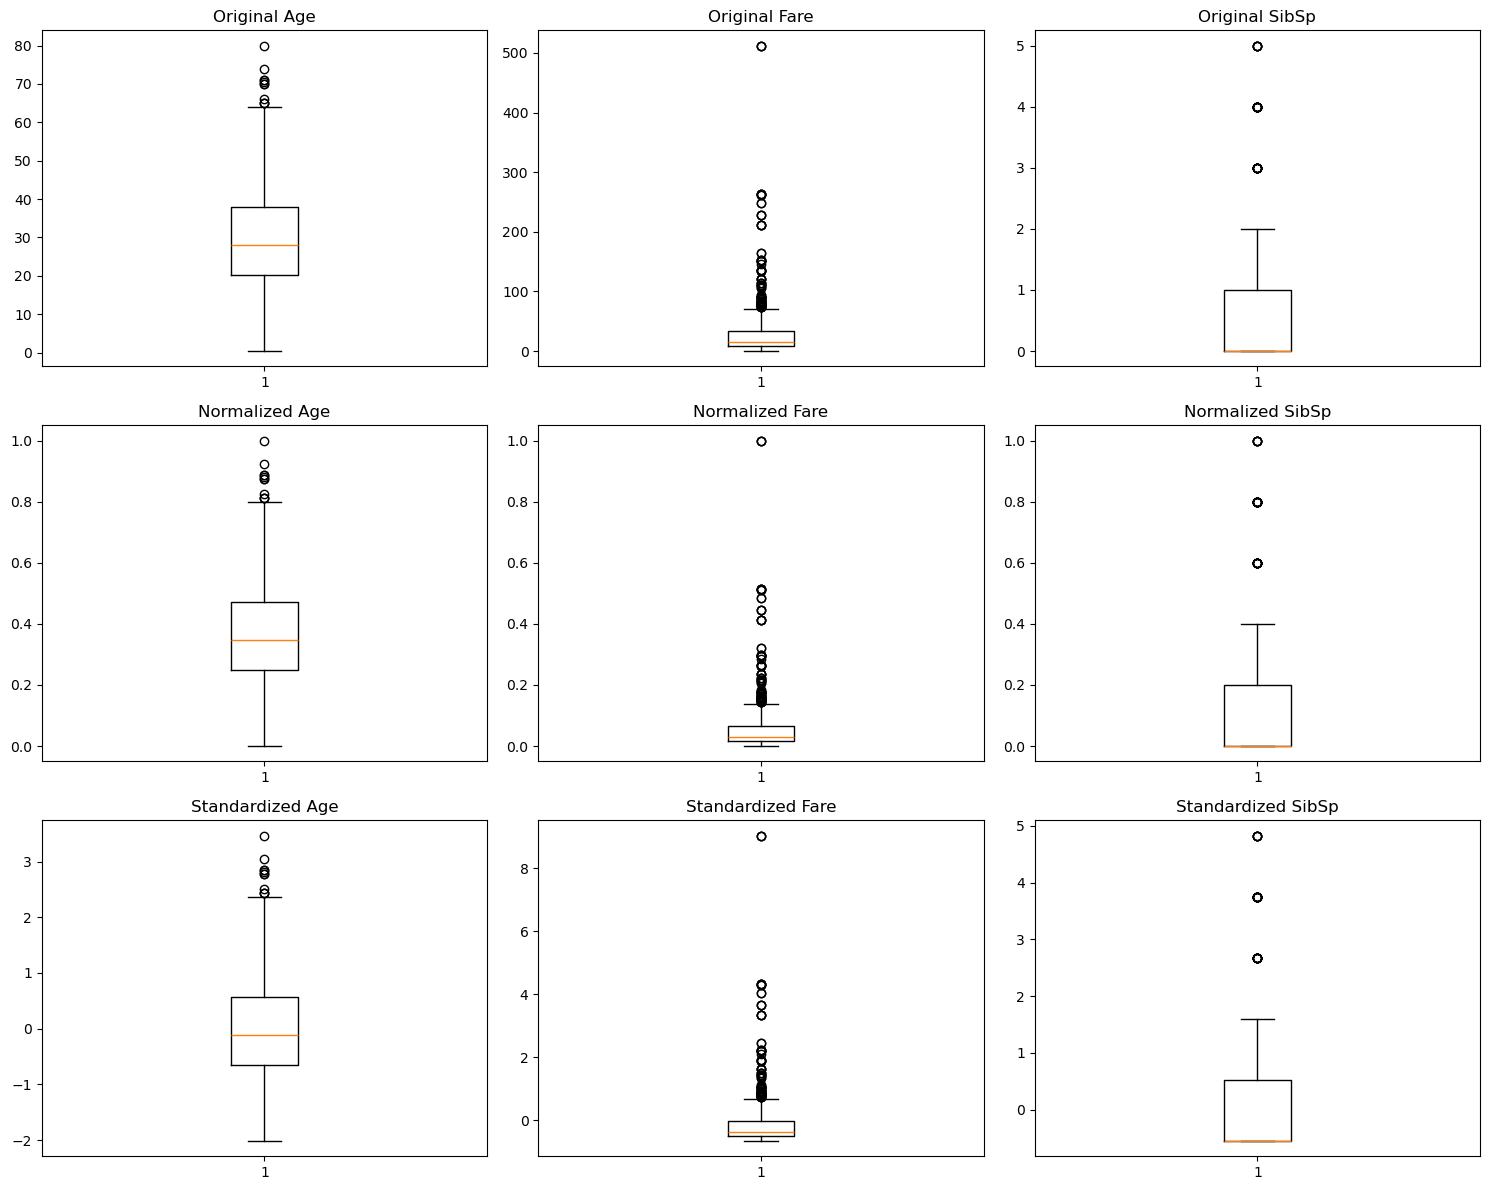

Original Data Statistics:
            Age        Fare     SibSp
min    0.420000    0.000000  0.000000
max   80.000000  512.329200  5.000000
mean  29.699118   34.694514  0.512605
std   14.526497   52.918930  0.929783

Normalized Data Statistics:
           Age      Fare     SibSp
min   0.000000  0.000000  0.000000
max   1.000000  1.000000  1.000000
mean  0.367921  0.067719  0.102521
std   0.182540  0.103291  0.185957

Standardized Data Statistics:
               Age          Fare         SibSp
min  -2.016979e+00 -6.560759e-01 -5.517031e-01
max   3.465126e+00  9.032109e+00  4.829663e+00
mean  2.338621e-16 -5.970947e-17 -4.975789e-18
std   1.000701e+00  1.000701e+00  1.000701e+00


In [14]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import pandas as pd
ur1="https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df=pd.read_csv(ur1)
df.head()


cols = ['Age', 'Fare', 'SibSp']
data = df[cols].dropna()

# MinMaxScaler (Normalization)
minmax_scaler = MinMaxScaler()
normalized_data = pd.DataFrame(minmax_scaler.fit_transform(data),columns=cols)

# StandardScaler (Standardization)
standard_scaler = StandardScaler()
standardized_data = pd.DataFrame(standard_scaler.fit_transform(data),columns=cols)

# box plots
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

# Original Data
for i, col in enumerate(cols):
    axes[0, i].boxplot(data[col])
    axes[0, i].set_title(f'Original {col}')

# Normalized Data
for i, col in enumerate(cols):
    axes[1, i].boxplot(normalized_data[col])
    axes[1, i].set_title(f'Normalized {col}')

# Standardized Data
for i, col in enumerate(cols):
    axes[2, i].boxplot(standardized_data[col])
    axes[2, i].set_title(f'Standardized {col}')

plt.tight_layout()
# plt.savefig("Statistic_Visualization.png", dpi=300, bbox_inches="tight")
plt.show()

print("Original Data Statistics:")
print(data.agg(['min', 'max', 'mean', 'std']))

print("\nNormalized Data Statistics:")
print(normalized_data.agg(['min', 'max', 'mean', 'std']))

print("\nStandardized Data Statistics:")
print(standardized_data.agg(['min', 'max', 'mean', 'std']))


# Observation:-



1. MinMaxScaler is more affected by outliers in the Fare column.
2. Choose normalization when features need to be in a fixed range (0-1),
   especially for distance-based algorithms and neural networks.
3. Choose standardization when data contains outliers or when
   algorithms assume normally distributed features.


## Q8 Outlier Detection and Removal — IQR Method

Q1: 7.9104
Q3: 31.0
IQR: 23.0896
Lower Fence: -26.724
Upper Fence: 65.6344
Rows before removal: 891
Rows after removal: 775


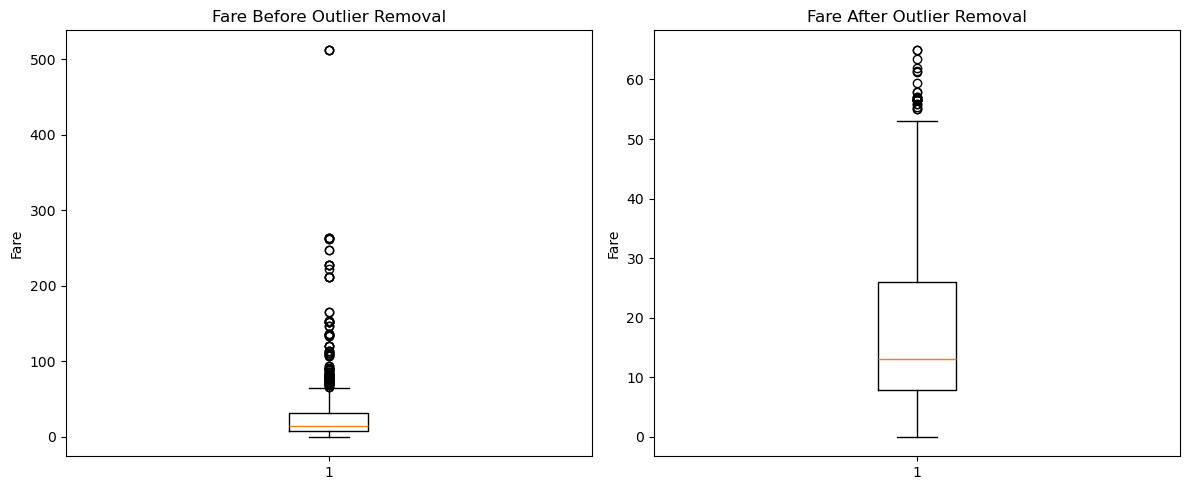

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
ur1="https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df=pd.read_csv(ur1)
df.head()

df.describe()

#IQR 
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1

# lower and upper fences
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

# Identify outliers
outliers = df[(df['Fare'] < lower_fence) | (df['Fare'] > upper_fence)]

# rows before remova
rows_before = df.shape[0]

# Remove outliers
df_no_outliers = df[(df['Fare'] >= lower_fence) & (df['Fare'] <= upper_fence)]

# Count rows after removal
rows_after = df_no_outliers.shape[0]

# Print results
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Fence:", lower_fence)
print("Upper Fence:", upper_fence)

print("Rows before removal:", rows_before)
print("Rows after removal:", rows_after)


# Box plot before removal
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.boxplot(df['Fare'].dropna())
plt.title('Fare Before Outlier Removal')
plt.ylabel('Fare')

# Box plot after removal
plt.subplot(1, 2, 2)
plt.boxplot(df_no_outliers['Fare'].dropna())
plt.title('Fare After Outlier Removal')
plt.ylabel('Fare')
# plt.savefig("Fare After Outlier Removal", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

# Observation :-

The number of rows decreased from 891 to 775.The box plot showed fewer extreme points.The Fare distribution became less right-skewed and more compact.The spread of the data reduced, making it more representative of the majority of passengers.

### Q9 Outlier Detection and Removal — Z-score Method

Number of outlier rows removed: 57
Rows before removal: 714
Rows after removal: 657


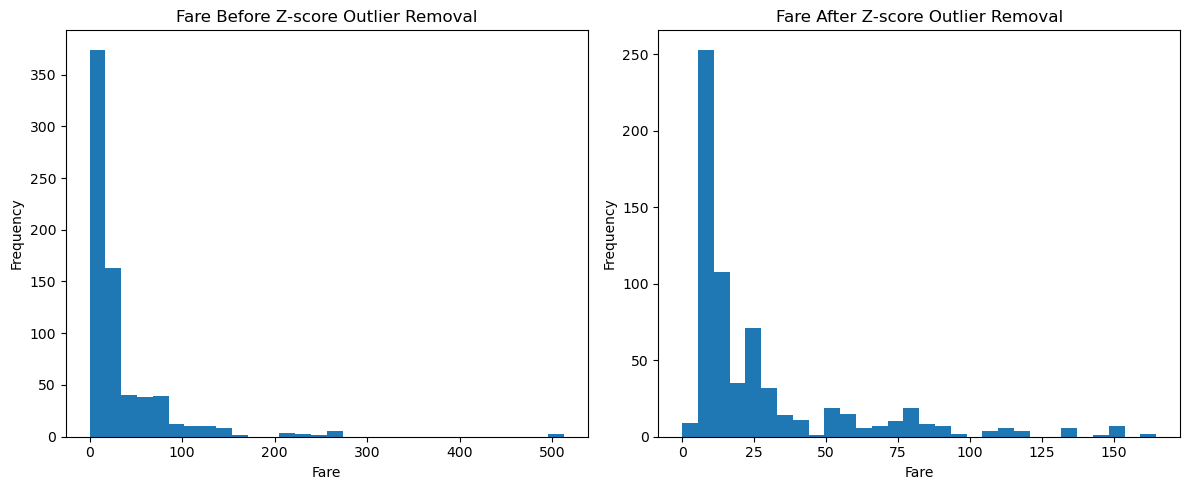

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import zscore
ur1="https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df=pd.read_csv(ur1)
df


num_cols = ['Age', 'Fare', 'SibSp', 'Parch']
df_z = df[num_cols].dropna()

# Z-scores
z_scores = np.abs(zscore(df_z))

# Identify rows where any Z-score > 3
outliers = (z_scores > 3).any(axis=1)

# Count outlier rows
num_outliers = outliers.sum()

# Remove outliers
df_no_outliers = df_z[~outliers]

# Print results
print("Number of outlier rows removed:", num_outliers)
print("Rows before removal:", len(df_z))
print("Rows after removal:", len(df_no_outliers))

# Histograms 
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df_z['Fare'], bins=30)
plt.title('Fare Before Z-score Outlier Removal')
plt.xlabel('Fare')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(df_no_outliers['Fare'], bins=30)
plt.title('Fare After Z-score Outlier Removal')
plt.xlabel('Fare')
plt.ylabel('Frequency')
# plt.savefig("Fare_Z_Score Outlier Removal.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()



# Observation:


 IQR method is more appropriate for skewed data like Fare
because it does not assume normal distribution and
is less affected by extreme values.

# Q10 Full End-to-End Preprocessing Pipeline

In [17]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
ur1="https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df=pd.read_csv(ur1)
df.head()


# Features and target
X = df.drop('Survived', axis=1)
y = df['Survived']

# Select numerical and categorical columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

# Numerical Pipeline
num_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')),('scaler', StandardScaler())])

# Categorical Pipeline
cat_pipeline = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Column Transformer
preprocessor = ColumnTransformer([('num', num_pipeline, num_cols),('cat', cat_pipeline, cat_cols)])

# Complete Pipeline
model = Pipeline([('preprocessor', preprocessor),('classifier', LogisticRegression(max_iter=1000))])

# Fit model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

print("Accuracy Score:", accuracy_score(y_test, y_pred))

# Shape of transformed feature matrix
X_train_transformed = model.named_steps['preprocessor'].transform(X_train)

print("\nShape of transformed feature matrix:")
print(X_train_transformed.shape)

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.88      0.85       105
           1       0.81      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179

Accuracy Score: 0.8212290502793296

Shape of transformed feature matrix:
(712, 1398)


# Observation:-

The pipeline successfully handled missing values, scaling, and encoding.OneHotEncoding and imputation had the greatest impact on model performance.StandardScaler helped Logistic Regression converge efficiently.